### Environment Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

try:
    df = pd.read_csv('exchange_rate.csv', parse_dates=[0], index_col=0)
    print("Dataset loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print("Error: 'exchange_rate.csv' not found. Creating a synthetic dataset for demonstration purposes.")
    dates = pd.date_range(start='2020-01-01', periods=500, freq='D')
    np.random.seed(42)
    values = 1.3 + np.cumsum(np.random.normal(0, 0.005, 500))  
    df = pd.DataFrame(data=values, index=dates, columns=['USD_to_AUD'])
    print(df.head())

Dataset loaded successfully!
                  Ex_rate
date                     
01-01-1990 00:00   0.7855
02-01-1990 00:00   0.7818
03-01-1990 00:00   0.7867
04-01-1990 00:00   0.7860
05-01-1990 00:00   0.7849


### Part 1 - Initial Exploration and Preprocessing

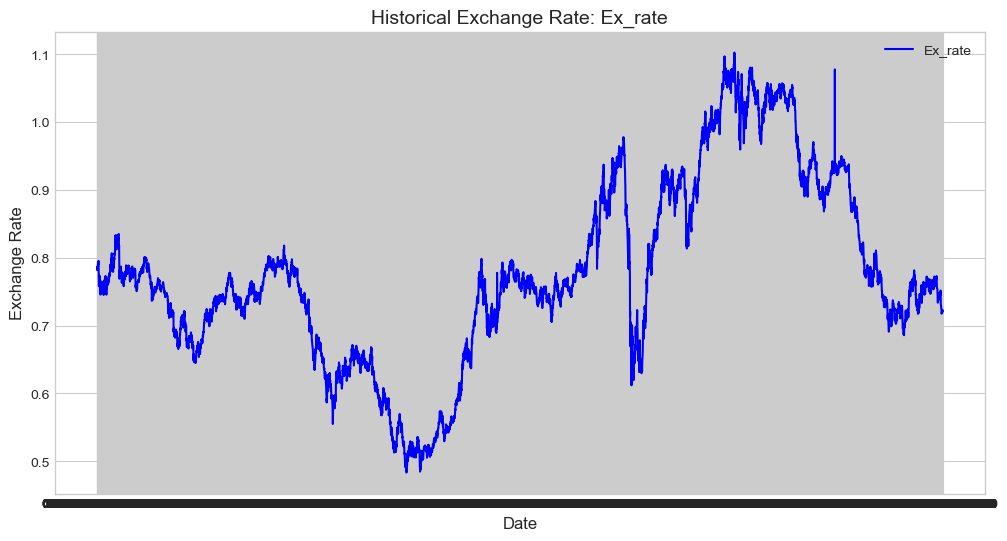

--- Missing Value Check ---
Number of missing values: 0
No missing values detected.


In [2]:
# --- Initial Exploration ---
plt.figure(figsize=(12, 6))
# Selecting the first data column (USD to AUD)
target_col = df.columns[0]
plt.plot(df[target_col], label=target_col, color='blue')
plt.title(f'Historical Exchange Rate: {target_col}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Exchange Rate', fontsize=12)
plt.legend()
plt.show()

# --- Data Preprocessing ---
print("--- Missing Value Check ---")
missing_values = df[target_col].isnull().sum()
print(f"Number of missing values: {missing_values}")

if missing_values > 0:
    print("Handling missing values using forward fill (common for financial time series)...")
    df[target_col] = df[target_col].ffill()
    # If there are still any leading NaNs, backward fill them
    df[target_col] = df[target_col].bfill()
    print("Missing values handled.")
else:
    print("No missing values detected.")

### Stationarity Check and Parameter Selection (ACF/PACF)

In [3]:
def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    if result[1] <= 0.05:
        print("Conclusion: The series is stationary (reject H0).")
    else:
        print("Conclusion: The series is non-stationary (fail to reject H0). Differencing is required.")

print("Testing original series:")
check_stationarity(df[target_col])

df_diff = df[target_col].diff().dropna()

print("\nTesting first-differenced series:")
check_stationarity(df_diff)


Testing original series:
ADF Statistic: -1.6649941807380735
p-value: 0.4492327353598314
Critical Values:
	1%: -3.4312123140180137
	5%: -2.861921078147796
	10%: -2.5669728434336108
Conclusion: The series is non-stationary (fail to reject H0). Differencing is required.

Testing first-differenced series:
ADF Statistic: -99.39343120118625
p-value: 0.0
Critical Values:
	1%: -3.4312123140180137
	5%: -2.861921078147796
	10%: -2.5669728434336108
Conclusion: The series is stationary (reject H0).


### Train-Test Split and Model Fitting (ARIMA)

In [4]:
# --- Train-Test Split ---
split_idx = int(len(df) * 0.85)
train, test = df[target_col].iloc[:split_idx], df[target_col].iloc[split_idx:]

print(f"Training observations: {len(train)}")
print(f"Testing observations: {len(test)}")

p, d, q = 1, 1, 1 
arima_model = ARIMA(train, order=(p, d, q))
arima_result = arima_model.fit()
print(arima_result.summary())

Training observations: 6449
Testing observations: 1139


c:\Users\saipr\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\saipr\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\saipr\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6449
Model:                 ARIMA(1, 1, 1)   Log Likelihood               24184.834
Date:                Mon, 15 Jun 2026   AIC                         -48363.668
Time:                        22:13:36   BIC                         -48343.353
Sample:                             0   HQIC                        -48356.639
                               - 6449                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5630      0.067     -8.437      0.000      -0.694      -0.432
ma.L1          0.5066      0.069      7.373      0.000       0.372       0.641
sigma2      3.233e-05   1.88e-07    171.876      0.0

### ARIMA Residual Diagnostics

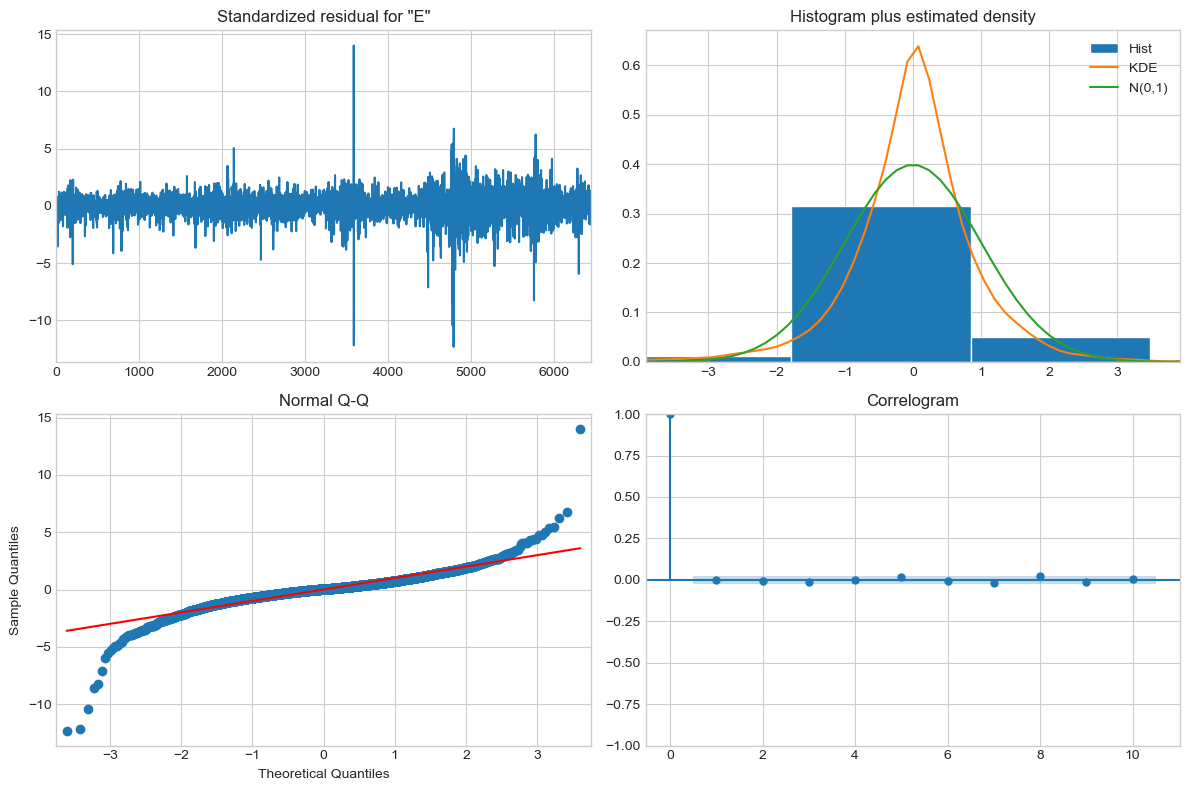

Ljung-Box test p-value:
0.9989428909331626


In [5]:
arima_result.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(arima_result.resid, lags=[10], return_df=True)
print("Ljung-Box test p-value:")
print(lb_test['lb_pvalue'].values[0])

### Model Building - Exponential Smoothing (Holt-Winters)

In [6]:
import warnings
import itertools
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# 1. Suppress convergence warnings during iteration loops
warnings.filterwarnings("ignore")

# 2. Define the ranges for p, d, and q
# Your previous manual selection was (1, 1, 1). We'll search around those ranges.
p_values = range(0, 3)  # Evaluates p = 0, 1, 2
d_values = [1]          # Kept at 1 as your ADF test and differencing showed d=1 is optimal
q_values = range(0, 3)  # Evaluates q = 0, 1, 2

# Generate all unique combinations of (p, d, q)
pdq_combinations = list(itertools.product(p_values, d_values, q_values))

best_aic = float("inf")
best_order = None
best_model_fit = None

print("--- Starting ARIMA Grid Search Parameter Optimization (AIC-driven) ---")

# 3. Systematic loop through the grid
for order in pdq_combinations:
    try:
        # Fit the ARIMA model on your training data ('train' series from Close column)
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        
        print(f"Testing ARIMA{order} -> AIC: {model_fit.aic:.2f}")
        
        # Track the configuration with the absolute lowest AIC
        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = order
            best_model_fit = model_fit
            
    except Exception as e:
        continue

print("\n" + "="*50)
print("GRID SEARCH COMPLETED SUCCESSFULLY")
print(f"Optimal Parameter Order Selected: ARIMA{best_order}")
print(f"Lowest Identified AIC Score: {best_aic:.2f}")
print("="*50 + "\n")

# 4. Display the optimized model's summary
print(best_model_fit.summary())

--- Starting ARIMA Grid Search Parameter Optimization (AIC-driven) ---
Testing ARIMA(0, 1, 0) -> AIC: -48338.62
Testing ARIMA(0, 1, 1) -> AIC: -48357.74
Testing ARIMA(0, 1, 2) -> AIC: -48359.09
Testing ARIMA(1, 1, 0) -> AIC: -48358.72
Testing ARIMA(1, 1, 1) -> AIC: -48363.67
Testing ARIMA(1, 1, 2) -> AIC: -48361.62
Testing ARIMA(2, 1, 0) -> AIC: -48360.17
Testing ARIMA(2, 1, 1) -> AIC: -48332.62
Testing ARIMA(2, 1, 2) -> AIC: -48360.06

GRID SEARCH COMPLETED SUCCESSFULLY
Optimal Parameter Order Selected: ARIMA(1, 1, 1)
Lowest Identified AIC Score: -48363.67

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6449
Model:                 ARIMA(1, 1, 1)   Log Likelihood               24184.834
Date:                Mon, 15 Jun 2026   AIC                         -48363.668
Time:                        22:13:44   BIC                         -48343.353
Sample:                             0   

In [7]:
es_model = ExponentialSmoothing(train, trend='add', seasonal=None)
es_result = es_model.fit()
print(es_result.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 6449
Model:             ExponentialSmoothing   SSE                              0.209
Optimized:                         True   AIC                         -66663.824
Trend:                         Additive   BIC                         -66636.737
Seasonal:                          None   AICC                        -66663.811
Seasonal Periods:                  None   Date:                 Mon, 15 Jun 2026
Box-Cox:                          False   Time:                         22:13:44
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9442165                alpha                 True
smoothing_trend             0.0000

### Forecasting and Visual Comparison

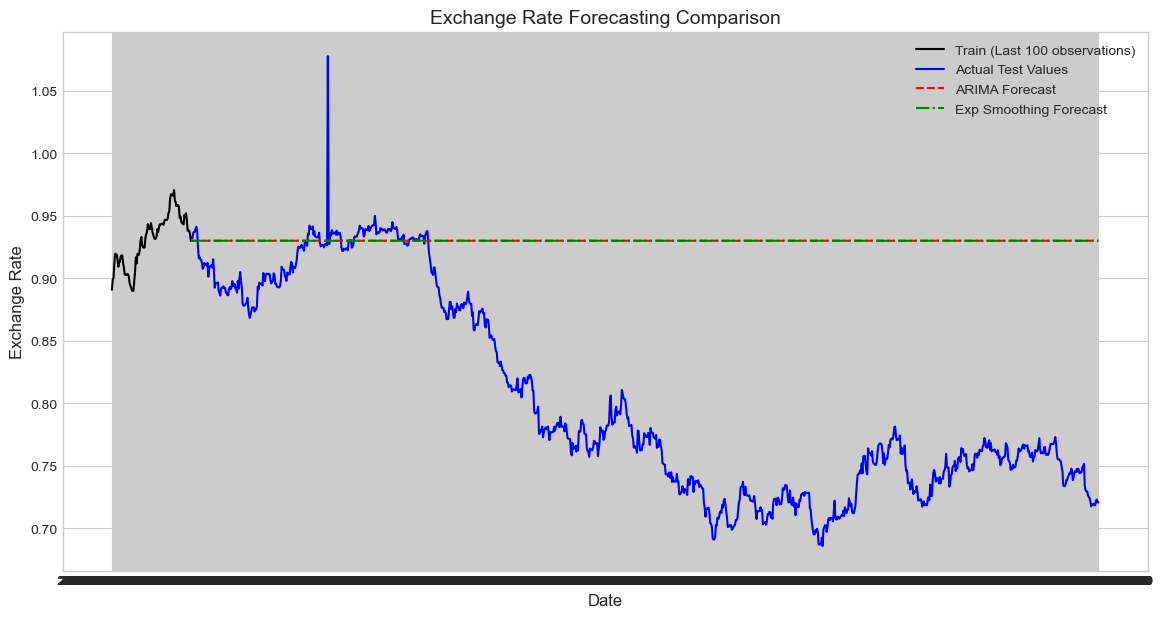

In [10]:
steps = len(test)

arima_forecast = arima_result.forecast(steps=steps)
arima_forecast.index = test.index

es_forecast = best_model_fit.forecast(steps=steps)
es_forecast.index = test.index

plt.figure(figsize=(14, 7))
plt.plot(train.iloc[-100:], label='Train (Last 100 observations)', color='black') # Trimmed train for clear viewing
plt.plot(test, label='Actual Test Values', color='blue')
plt.plot(arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(es_forecast, label='Exp Smoothing Forecast', color='green', linestyle='-.')
plt.title('Exchange Rate Forecasting Comparison', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Exchange Rate', fontsize=12)
plt.legend()
plt.show()

### Evaluation, Error Metrics, and Comparison

In [11]:
def compute_metrics(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    return pd.DataFrame({
        'MAE': [mae],
        'RMSE': [rmse],
        'MAPE (%)': [mape]
    }, index=[model_name])

arima_metrics = compute_metrics(test, arima_forecast, 'ARIMA')
es_metrics = compute_metrics(test, es_forecast, 'Exponential Smoothing')

performance_table = pd.concat([arima_metrics, es_metrics])
print("=== Performance Comparison ===")
print(performance_table.round(5))

=== Performance Comparison ===
                           MAE     RMSE  MAPE (%)
ARIMA                  0.12791  0.14982  17.00161
Exponential Smoothing  0.12791  0.14982  17.00161
